# Detecção de Discurso de Ódio em Português com CNN — OffComBR2

**Configurações padronizadas:**
- Dataset: OffComBR2 (formato ARFF, carregado via GitHub)
- Split: 80% treino / 20% teste, com `stratify=y` e `random_state=42`
- Pré-processamento: lowercase, remoção de URLs, menções, pontuação e números
- Métrica principal: F1-score macro

## 1. Importações

In [1]:
import os
import re
import string
import csv
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

print('TensorFlow version:', tf.__version__)

2026-02-19 00:30:27.175115: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0


## 2. Carregamento da base de dados (formato ARFF)

In [2]:
url = 'https://raw.githubusercontent.com/rogersdepelle/OffComBR/master/OffComBR2.arff'
response = requests.get(url)
response.raise_for_status()

lines = response.text.splitlines()
data_start = next(i for i, l in enumerate(lines) if l.strip().lower() == '@data') + 1

records = []
reader = csv.reader(lines[data_start:])
for row in reader:
    if len(row) < 2:
        continue
    cls = row[0].strip()
    doc = row[1].strip().strip("'\"")
    if cls in ('yes', 'no'):
        records.append({'text': doc, 'label': 1 if cls == 'yes' else 0})

df = pd.DataFrame(records)

print(f'Total de amostras: {len(df)}')
print(f'Distribuição de classes:\n{df["label"].value_counts()}')
print(f'Taxa de conteúdo ofensivo: {df["label"].mean():.1%}')

Total de amostras: 1250
Distribuição de classes:
label
0    831
1    419
Name: count, dtype: int64
Taxa de conteúdo ofensivo: 33.5%


## 3. Pré-processamento de texto

In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#\w+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)

lengths = df['text_clean'].str.split().apply(len)
print(f'Comprimento médio: {lengths.mean():.1f} tokens')
print(f'Percentil 95: {np.percentile(lengths, 95):.0f} tokens')

Comprimento médio: 13.0 tokens
Percentil 95: 36 tokens


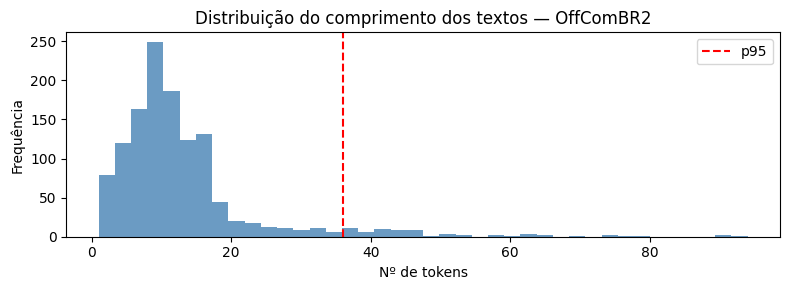

In [4]:
plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='steelblue', alpha=0.8)
plt.axvline(np.percentile(lengths, 95), color='red', linestyle='--', label='p95')
plt.xlabel('Nº de tokens')
plt.ylabel('Frequência')
plt.title('Distribuição do comprimento dos textos — OffComBR2')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Tokenização e padding

In [5]:
MAX_WORDS = 20000
MAX_LEN = int(np.percentile(lengths, 95))
print(f'max_len definido como: {MAX_LEN}')

tokenizer_keras = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_keras.fit_on_texts(df['text_clean'])

sequences = tokenizer_keras.texts_to_sequences(df['text_clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label'].values

print(f'Shape de X: {X.shape}')

max_len definido como: 36
Shape de X: (1250, 36)


## 5. Divisão treino/teste

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treinamento: {X_train.shape[0]} amostras')
print(f'Teste:       {X_test.shape[0]} amostras')

Treinamento: 1000 amostras
Teste:       250 amostras


## 6. Arquitetura da CNN

In [7]:
EMBED_DIM = 128

model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/home/heliocm/.local/lib/python3.9/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-02-19 00:30:54.602368: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-02-19 00:30:54.602400: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-02-19 00:30:54.602406: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-02-19 00:30:54.602415: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-02-19 00:30:54.602422: I external/local_xla/xla/stream_ex

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 7. Treinamento com EarlyStopping

In [8]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('cnn_offcombr2_best.h5', monitor='val_loss', save_best_only=True, verbose=0)
]

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
27/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6832 - loss: 0.6405

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6811 - loss: 0.6405 - val_accuracy: 0.6600 - val_loss: 0.6174
Epoch 2/20
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6767 - loss: 0.5858

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6761 - loss: 0.5837 - val_accuracy: 0.6600 - val_loss: 0.5799
Epoch 3/20
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7144 - loss: 0.4803

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7207 - loss: 0.4773 - val_accuracy: 0.6900 - val_loss: 0.5400
Epoch 4/20
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9281 - loss: 0.2797

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9288 - loss: 0.2778 - val_accuracy: 0.7700 - val_loss: 0.5258
Epoch 5/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9826 - loss: 0.0989 - val_accuracy: 0.7800 - val_loss: 0.6033
Epoch 6/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9947 - loss: 0.0402 - val_accuracy: 0.7600 - val_loss: 0.6660
Epoch 7/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9930 - loss: 0.0287 - val_accuracy: 0.7800 - val_loss: 0.7129
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 4.


## 8. Curvas de aprendizado

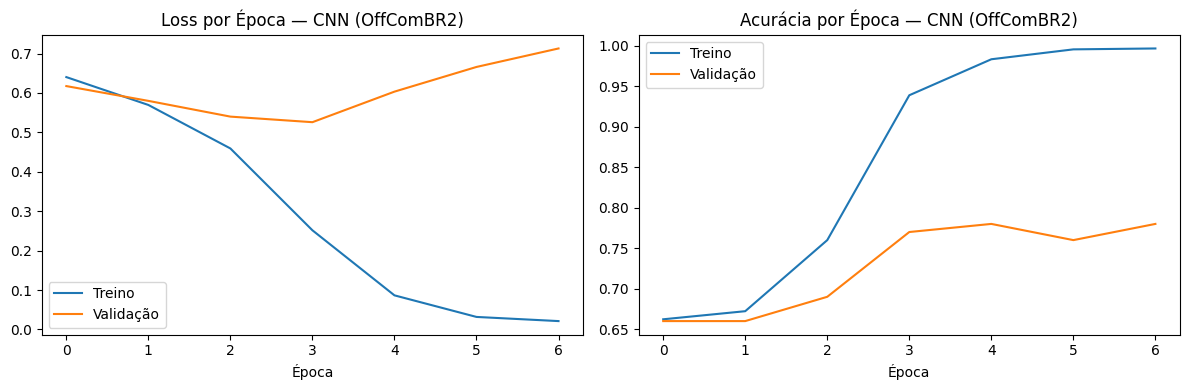

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validação')
axes[0].set_title('Loss por Época — CNN (OffComBR2)')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validação')
axes[1].set_title('Acurácia por Época — CNN (OffComBR2)')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Avaliação no conjunto de teste

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


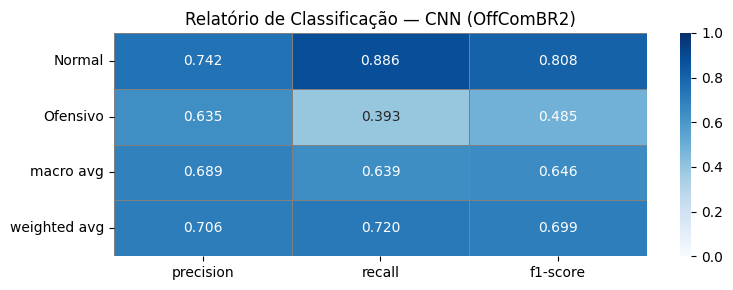

F1-score Macro: 0.6465


In [10]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Relatório de classificação como imagem
report_dict = classification_report(y_test, y_pred, target_names=['Normal', 'Ofensivo'], output_dict=True)
df_report = pd.DataFrame(report_dict).T.drop('accuracy', errors='ignore')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    df_report[['precision', 'recall', 'f1-score']].astype(float),
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=1
)
ax.set_title('Relatório de Classificação \u2014 CNN (OffComBR2)')
plt.tight_layout()
plt.savefig('report_cnn_offcombr2.png', dpi=150, bbox_inches='tight')
plt.show()

f1_macro = report_dict['macro avg']['f1-score']
print(f'F1-score Macro: {f1_macro:.4f}')

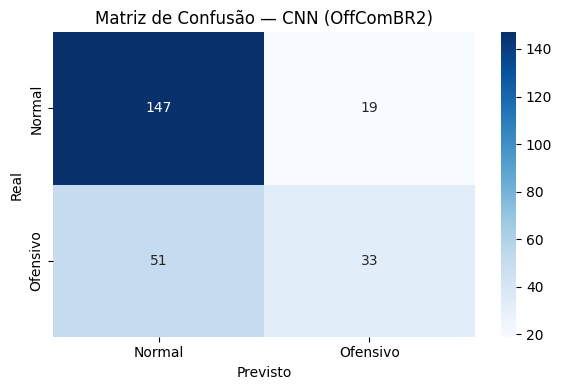

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ofensivo'],
            yticklabels=['Normal', 'Ofensivo'])
plt.title('Matriz de Confusão — CNN (OffComBR2)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [40]:
# ANALISE_QUALITATIVA_PATCH
import pandas as _pd, numpy as _np, os as _os

from sklearn.model_selection import train_test_split as _tts
_, _idx = _tts(np.arange(len(df)), test_size=0.2,
               stratify=df['label'], random_state=42)
_texts = df['text'].values[_idx]

# Índices de FP e FN
_fp_idx = _np.where((y_test == 0) & (y_pred == 1))[0]
_fn_idx = _np.where((y_test == 1) & (y_pred == 0))[0]

_rng = _np.random.default_rng(42)
_fp_s = _rng.choice(_fp_idx, size=min(10, len(_fp_idx)), replace=False) if len(_fp_idx) else _np.array([], int)
_fn_s = _rng.choice(_fn_idx, size=min(10, len(_fn_idx)), replace=False) if len(_fn_idx) else _np.array([], int)

_rows = []
for _i in _fp_s:
    _rows.append({'modelo': 'CNN', 'dataset': 'OffComBR2',
                   'tipo': 'Falso Positivo', 'texto': _texts[_i],
                   'rotulo_real': int(y_test[_i]), 'predicao': int(y_pred[_i])})
for _i in _fn_s:
    _rows.append({'modelo': 'CNN', 'dataset': 'OffComBR2',
                   'tipo': 'Falso Negativo', 'texto': _texts[_i],
                   'rotulo_real': int(y_test[_i]), 'predicao': int(y_pred[_i])})

_csv = 'analisequalitativa.csv'
_df_new = _pd.DataFrame(_rows)
if _os.path.exists(_csv):
    _df_existing = _pd.read_csv(_csv)
    # Remove entradas anteriores do mesmo modelo/dataset antes de adicionar
    _df_existing = _df_existing[
        ~((_df_existing['modelo'] == 'CNN') & (_df_existing['dataset'] == 'OffComBR2'))
    ]
    _df_new = _pd.concat([_df_existing, _df_new], ignore_index=True)
_df_new.to_csv(_csv, index=False)

# Também expõe _texts para a célula de gráfico (se houver)
texts_qualitativa = _texts

print(f'Exportados {len(_fp_s)} FP e {len(_fn_s)} FN → {_csv}')
print(f'Total no arquivo: {len(_df_new)} linhas')

Exportados 10 FP e 10 FN → analisequalitativa.csv
Total no arquivo: 80 linhas
